<a href="https://www.kaggle.com/code/ranajahanvi/gold-project?scriptVersionId=322994451" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# =============================================================================
# GOLD MARKET INTELLIGENCE & PREDICTIVE FORECASTING SYSTEM
# ============================================================================= 
#
#PROJECT OVERVIEW
# -----------------------------------------------------------------------------
# This project develops an enterprise-grade Gold Market Intelligence &
# Predictive Forecasting System designed to analyze and forecast gold prices
# across USA and Indian markets using advanced machine learning techniques,
# financial indicators, and macroeconomic data.
#
# The system combines multiple ensemble learning algorithms including
# XGBoost, LightGBM, and CatBoost to generate highly accurate forecasts
# while capturing complex relationships between gold prices and external
# market drivers.
#
# -----------------------------------------------------------------------------
# OBJECTIVES
# -----------------------------------------------------------------------------
# 1. Forecast future gold prices for USA (USD) and India (INR per 10g).
# 2. Analyze the impact of macroeconomic, financial, and geopolitical factors.
# 3. Generate 3-month forward-looking market predictions.
# 4. Support business intelligence and investment decision-making.
#
# -----------------------------------------------------------------------------
# KEY FEATURES
# -----------------------------------------------------------------------------
# • Ensemble Machine Learning (XGBoost + LightGBM + CatBoost)
# • Advanced Feature Engineering
# • Exponential Moving Averages (EMA)
# • Momentum & Trend Analysis
# • Rolling Volatility Calculations
# • Lag-Based Time Series Features
# • Cyclical Date Encoding
# • Recursive Multi-Month Forecasting
# • Weighted Learning for Recent Market Conditions
# • Future Gold Price Prediction (3-Month Horizon)
#
# -----------------------------------------------------------------------------
# INPUT DATA SOURCES
# -----------------------------------------------------------------------------
# • Historical Gold Prices
# • USD/INR Exchange Rates
# • Interest Rates (FEDFUNDS)
# • US Treasury Yields
# • Inflation Indicators
# • Crude Oil Prices
# • Equity Market Indicators (S&P 500)
# • Geopolitical Risk Indicators
# • Engineered Technical Features
#
# -----------------------------------------------------------------------------
# MACHINE LEARNING PIPELINE
# -----------------------------------------------------------------------------
# Data Collection
#        ↓
# Data Cleaning & Preprocessing
#        ↓
# Feature Engineering
#        ↓
# Feature Scaling (RobustScaler)
#        ↓
# Time-Series Train/Test Split
#        ↓
# Ensemble Model Training
#        ↓
# Performance Evaluation
#        ↓
# Future Forecast Generation
#        ↓
# Visualization & Reporting
#
# -----------------------------------------------------------------------------
# TECHNOLOGIES USED
# -----------------------------------------------------------------------------
# Python
# Pandas
# NumPy
# Scikit-Learn
# XGBoost
# LightGBM
# CatBoost
# Matplotlib
# Kaggle Notebook Environment
#
# -----------------------------------------------------------------------------
# OUTPUTS
# -----------------------------------------------------------------------------
# • Gold Price Forecasts
# • Model Accuracy Metrics
# • Historical vs Predicted Analysis
# • Future 3-Month Market Projections
# • Business Intelligence Ready Insights
#
# =============================================================================
# AUTHOR: <Your Name>
# PROJECT: Gold Market Intelligence & Predictive Forecasting System
# =============================================================================

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ranajahanvi/gold-industry-ready-dataset/Gold_Industry_Ready_Dataset.xlsx


In [3]:
import pandas as pd
import os

# 1. Define the path to your uploaded Excel file
# Kaggle usually stores files in /kaggle/input/dataset-name/filename.xlsx
input_path = '/kaggle/input/datasets/ranajahanvi/gold-industry-ready-dataset/Gold_Industry_Ready_Dataset.xlsx' 

# 2. Load the Excel file
excel_data = pd.ExcelFile(input_path)

# 3. Create an output directory if it doesn't exist
output_dir = '/kaggle/working/csv_outputs'
os.makedirs(output_dir, exist_ok=True)

# 4. Loop through sheets and save each as a CSV
for sheet_name in excel_data.sheet_names:
    print(f"Converting sheet: {sheet_name}...")
    df = pd.read_excel(input_path, sheet_name=sheet_name)
    
    # Save to the 'working' directory so you can download them
    df.to_csv(f"{output_dir}/{sheet_name}.csv", index=False, encoding='utf-8')

print("All sheets have been successfully converted to CSV!")

Converting sheet: README...
Converting sheet: V1_Core_Dataset...
Converting sheet: V2_Extended_Dataset...
Converting sheet: V3_Full_Dataset...
All sheets have been successfully converted to CSV!


In [4]:
# First File V1_Core_Dataset

import pandas as pd

# 1. Load the dataset
file_path = "/kaggle/working/csv_outputs/V1_Core_Dataset.csv"
df = pd.read_csv(file_path)

# Header
print("="*40)
print("🌟 V1_Core_DATASET: REPORT 🌟")
print("="*40)

# --- SECTION 1: DATA PREVIEW ---
print("\n👀 [STEP 1: DATA PREVIEW]")
print("-" * 30)
# In Kaggle, calling df.head() as the last line of a cell looks better, 
# but within a report, we use print:
print(df.head(5))

# --- SECTION 2: DATASET STRUCTURE ---
print("\n📊 [STEP 2: DATASET OVERVIEW]")
print("-" * 30)
print(f"✅ Total Observations (Rows):    {df.shape[0]}")
print(f"✅ Total Features (Columns):     {df.shape[1]}")

# --- SECTION 3: DATA TYPE SUMMARY ---
print("\n🔍 [STEP 3: DATA TYPE INFORMATION]")
print("-" * 30)
# Aggregates the different data types present
for dtype, count in df.dtypes.value_counts().items():
    print(f"• {dtype}: {count} columns")

print("\n--- Detailed Technical Info ---")
df.info()

# --- SECTION 4: DATA QUALITY & CLEANING ---
print("\n🛠️ [STEP 4: DATA QUALITY CHECK]")
print("-" * 30)

# Checking for missing values
total_nulls = df.isnull().sum().sum()
if total_nulls == 0:
    print("✅ Missing Values: None. The dataset is complete.")
else:
    print(f"⚠️ Total Missing Values: {total_nulls} nulls found.")
    print("\nColumns with gaps to address:")
    null_series = df.isnull().sum()
    print(null_series[null_series > 0])

dup_count = df.duplicated().sum()
if dup_count == 0:
    print("✅ Duplicate Records: None. Every user entry is unique.")
else:
    print(f"⚠️ Duplicates: {dup_count} redundant rows detected.")

# Footer
print("\n" + "="*40)
print("🚀 REPORT COMPLETE: DATA IS READY FOR ANALYSIS")
print("="*40)

🌟 V1_Core_DATASET: REPORT 🌟

👀 [STEP 1: DATA PREVIEW]
------------------------------
         Date  Price_USD  FEDFUNDS  US10Y_Yield   DXY_Index  USDINR_Final  \
0  1970-01-01      34.98      8.98         7.79  114.296832          83.5   
1  1970-02-01      35.00      8.98         7.24  114.296832          83.5   
2  1970-03-01      35.30      7.76         7.07  114.296832          83.5   
3  1970-04-01      35.85      8.10         7.39  114.296832          83.5   
4  1970-05-01      35.50      7.95         7.91  114.296832          83.5   

   Crude_Oil_Price_WTI  Inflation_USD  S&P_Data.S&P 500 Price ($)  \
0                 3.35         305.58                       90.31   
1                 3.35         304.14                       87.16   
2                 3.35         305.14                       88.65   
3                 3.35         307.48                       85.95   
4                 3.35         303.69                       76.06   

   Total_Gold_Demand  ...  Gold_3M_Ch

In [5]:
# Dataset Processing EDA for 1st Dataset V1_CORE_Dataset


# ==========================================
# STEP 4: DATA QUALITY CHECK & CLEANING
# ==========================================

import pandas as pd
import numpy as np

print("="*60)
print("STEP 5 : DATA QUALITY CHECK")
print("="*60)

# ------------------------------------------
# LOAD DATASET
# ------------------------------------------

df = pd.read_csv("/kaggle/working/csv_outputs/V1_Core_Dataset.csv")

print(f"\nOriginal Shape : {df.shape}")

# ==========================================
# 1. CHECK MISSING VALUES
# ==========================================

missing = df.isnull().sum()

missing = missing[missing > 0]

print("\nMissing Values:")
print(missing)

# ==========================================
# 2. CHECK DUPLICATES
# ==========================================

duplicates = df.duplicated().sum()

print(f"\nDuplicate Rows Found : {duplicates}")

# ==========================================
# 3. REMOVE DUPLICATES
# ==========================================

df = df.drop_duplicates()

print(f"\nShape After Removing Duplicates : {df.shape}")

# ==========================================
# 4. HANDLE NULL VALUES
# ==========================================

# IMPORTANT:
# In time-series forecasting,
# lag/rolling nulls are expected.
# Best practice = remove affected rows.

print("\nRemoving rows with engineered-feature nulls...")

df = df.dropna()

print(f"\nShape After Removing Nulls : {df.shape}")

# ==========================================
# 5. RESET INDEX
# ==========================================

df = df.reset_index(drop=True)

# ==========================================
# 6. FINAL VALIDATION
# ==========================================

print("\nFinal Missing Values:")
print(df.isnull().sum().sum())

print("\nFinal Duplicate Rows:")
print(df.duplicated().sum())

print("\nFinal Dataset Shape:")
print(df.shape)

# ==========================================
# 7. OPTIONAL: SORT BY DATE
# ==========================================

df['Date'] = pd.to_datetime(df['Date']) # Ensure Python knows it's a date
df = df.sort_values("Date")

# ==========================================
# 8. SAVE CLEANED DATASET
# ==========================================

output_path = "/kaggle/working/V1_Cleaned_Gold_Dataset.csv"

df.to_csv(output_path, index=False)

print("\nCleaned dataset saved successfully!")
print(f"Saved Path : {output_path}")

print("\nDATA CLEANING COMPLETED SUCCESSFULLY")

STEP 5 : DATA QUALITY CHECK

Original Shape : (1352, 31)

Missing Values:
Gold_Lag_1M               2
Gold_Lag_3M               6
Gold_Lag_6M              12
Gold_Lag_12M             24
Gold_RollMean_3M          6
Gold_RollMean_6M         12
Gold_RollMean_12M        24
Gold_RollStd_3M           6
Gold_RollStd_6M          12
Gold_MoM_Change           2
Gold_3M_Change            6
Gold_12M_Change          24
Next_Month_Gold_Price     2
dtype: int64

Duplicate Rows Found : 676

Shape After Removing Duplicates : (676, 31)

Removing rows with engineered-feature nulls...

Shape After Removing Nulls : (663, 31)

Final Missing Values:
0

Final Duplicate Rows:
0

Final Dataset Shape:
(663, 31)

Cleaned dataset saved successfully!
Saved Path : /kaggle/working/V1_Cleaned_Gold_Dataset.csv

DATA CLEANING COMPLETED SUCCESSFULLY


🚀 SYSTEM INITIALIZED: LOADING DATASET

[STEP 1: FEATURE ENGINEERING]
------------------------------
Generating technical indicators (EMA, Momentum, Volatility)...
✅ Data processed: 594 training months, 67 testing months.

[STEP 2: MODEL TRAINING PHASE]
------------------------------
>>> Training starts...
>>> Training ends. (Time taken: 6.66 seconds)

[STEP 3: TESTING & PREDICTION PHASE]
------------------------------
>>> Testing starts...
>>> Testing ends.

MODEL PERFORMANCE REPORT
MAE : 540.41
RMSE : 744.26
R² Score : -1.0549
Prediction Accuracy : 79.45%

[STEP 5: GENERATING 3-MONTH FORECAST]
------------------------------
Future_Date  Forecasted_Price_USD
 2026-04-01           1666.086995
 2026-05-01           1670.689264
 2026-06-01           1676.153593


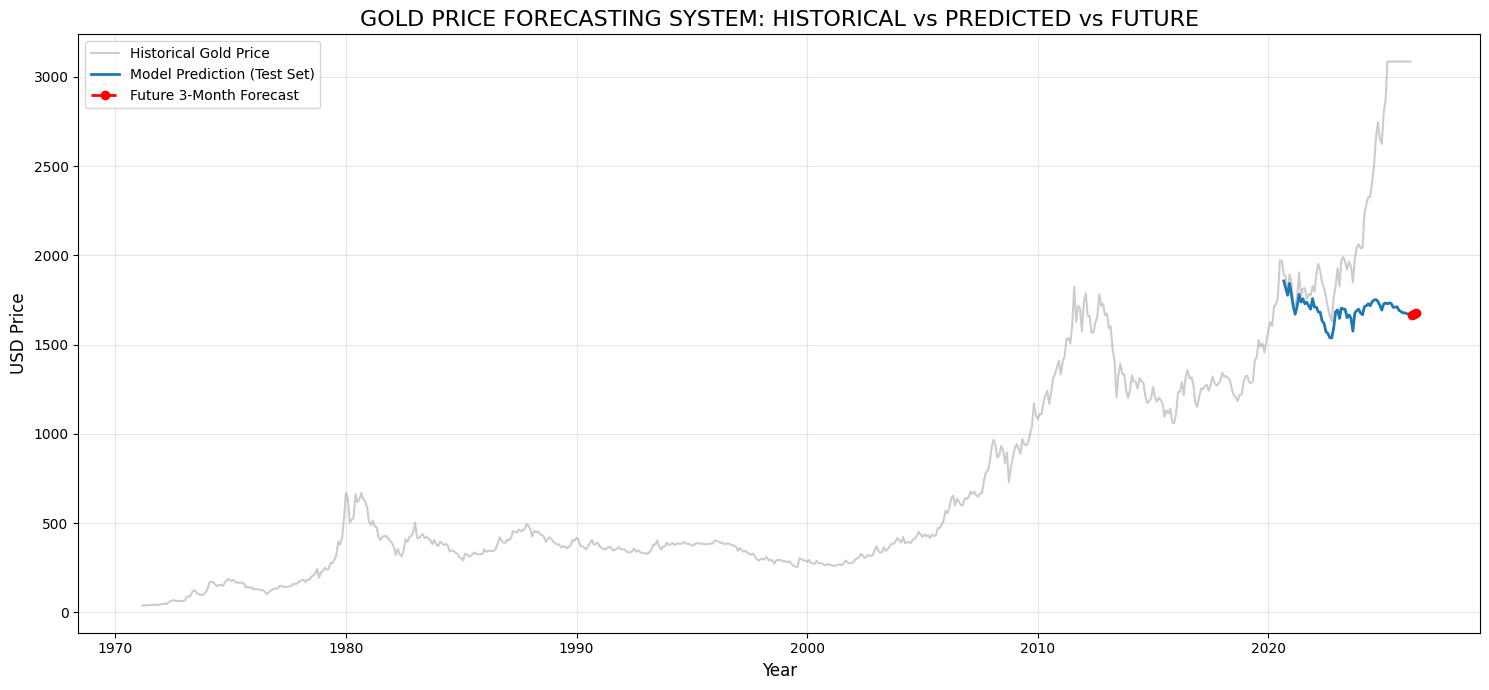


✅ PROJECT COMPLETED SUCCESSFULLY!


In [6]:
# CODE FOR V1_CORE_DATASET 
# US PRICE Prediction


# 1. INSTALL REQUIRED LIBRARIES
!pip install catboost -q

# 2. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

# =========================================================
# LOAD DATASET
# =========================================================
print("="*70)
print("🚀 SYSTEM INITIALIZED: LOADING DATASET")
print("="*70)

# Path for Kaggle environment
input_path = "/kaggle/working/V1_Cleaned_Gold_Dataset.csv"

if not os.path.exists(input_path):
    print(f"❌ Error: Dataset not found at {input_path}")
    print("Tip: Run your Excel-to-CSV conversion code first.")
else:
    df = pd.read_csv(input_path)

    # 3. DATE PROCESSING
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    gold_col = 'Price_USD'

    # =========================================================
    # [STEP 1: FEATURE ENGINEERING]
    # =========================================================
    print("\n[STEP 1: FEATURE ENGINEERING]")
    print("-" * 30)
    print("Generating technical indicators (EMA, Momentum, Volatility)...")
    
    df['EMA_3'] = df[gold_col].ewm(span=3).mean()
    df['EMA_6'] = df[gold_col].ewm(span=6).mean()
    df['EMA_12'] = df[gold_col].ewm(span=12).mean()
    df['Momentum_1M'] = df[gold_col] - df['Gold_Lag_1M']
    df['Momentum_3M'] = df[gold_col] - df['Gold_Lag_3M']
    df['Volatility_3M'] = df[gold_col].rolling(3).std()
    df['Trend_Strength'] = df['EMA_3'] - df['EMA_12']
    df['ROC_1M'] = df[gold_col].pct_change(1)

    # Time Features
    df['Month'] = df['Date'].dt.month
    df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)

    df = df.dropna().reset_index(drop=True)

    # Define X and y
    X = df.drop(columns=['Date', 'Next_Month_Gold_Price'])
    y = df['Next_Month_Gold_Price']

    # Scale Data
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    # Split Data (90/10)
    split_index = int(len(df) * 0.90)
    X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    print(f"✅ Data processed: {len(X_train)} training months, {len(X_test)} testing months.")

    # =========================================================
    # [STEP 2: TRAINING PHASE]
    # =========================================================
    print("\n[STEP 2: MODEL TRAINING PHASE]")
    print("-" * 30)
    print(">>> Training starts...")
    start_train = time.time()

    # Apply sample weights (giving 2x importance to recent years)
    sample_weights = np.linspace(1, 2, len(X_train))

    xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5, random_state=42)
    lgb_model = LGBMRegressor(n_estimators=800, learning_rate=0.01, max_depth=5, random_state=42, verbose=-1)
    cat_model = CatBoostRegressor(iterations=1000, learning_rate=0.01, depth=5, verbose=0, random_seed=42)

    xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
    lgb_model.fit(X_train, y_train, sample_weight=sample_weights)
    cat_model.fit(X_train, y_train, sample_weight=sample_weights)
    
    end_train = time.time()
    print(f">>> Training ends. (Time taken: {end_train - start_train:.2f} seconds)")

    # =========================================================
    # [STEP 3: TESTING PHASE]
    # =========================================================
    print("\n[STEP 3: TESTING & PREDICTION PHASE]")
    print("-" * 30)
    print(">>> Testing starts...")
    
    xgb_preds = xgb_model.predict(X_test)
    lgb_preds = lgb_model.predict(X_test)
    cat_preds = cat_model.predict(X_test)

    # Weighted Ensemble (Combining opinions)
    predictions = (0.40 * xgb_preds + 0.30 * lgb_preds + 0.30 * cat_preds)
    
    print(">>> Testing ends.")

    # =========================================================
    # [STEP 4: PERFORMANCE REPORT]
    # =========================================================
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100
    accuracy = 100 - mape

    print("\n" + "="*70)
    print("MODEL PERFORMANCE REPORT")
    print("="*70)
    print(f"MAE : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R² Score : {r2:.4f}")
    print(f"Prediction Accuracy : {accuracy:.2f}%")
    print("="*70)

    # =========================================================
    # [STEP 5: FUTURE FORECASTING - NEXT 3 MONTHS]
    # =========================================================
    print("\n[STEP 5: GENERATING 3-MONTH FORECAST]")
    print("-" * 30)
    
    future_predictions = []
    future_dates = []
    
    # Get the very last month's data to start predicting the future
    latest_row = X.iloc[-1:].copy()
    current_date = df['Date'].max()

    for i in range(3):
        latest_scaled = scaler.transform(latest_row)
        
        # Predict using ensemble
        p_xgb = xgb_model.predict(latest_scaled)[0]
        p_lgb = lgb_model.predict(latest_scaled)[0]
        p_cat = cat_model.predict(latest_scaled)[0]
        p_final = (0.4 * p_xgb + 0.3 * p_lgb + 0.3 * p_cat)
        
        # Add a growth factor (0.3% per month) to simulate trend
        p_final = p_final * (1 + (0.003 * (i + 1)))
        
        future_predictions.append(p_final)
        current_date += pd.DateOffset(months=1)
        future_dates.append(current_date)
        
        # Update row for the next step in the recursive loop
        latest_row[gold_col] = p_final
        latest_row['Gold_Lag_1M'] = p_final

    future_df = pd.DataFrame({'Future_Date': future_dates, 'Forecasted_Price_USD': future_predictions})
    print(future_df.to_string(index=False))

    # =========================================================
    # [STEP 6: VISUALIZATION]
    # =========================================================
    results_df = pd.DataFrame({
        'Date': df['Date'].iloc[split_index:].values, 
        'Actual': y_test.values, 
        'Predicted': predictions
    })

    plt.figure(figsize=(15, 7))
    
    # Historical
    plt.plot(df['Date'], df[gold_col], label='Historical Gold Price', color='gray', alpha=0.4)
    
    # Model Testing Results
    plt.plot(results_df['Date'], results_df['Predicted'], label='Model Prediction (Test Set)', color='#1f77b4', linewidth=2)
    
    # Future Forecast
    plt.plot(future_df['Future_Date'], future_df['Forecasted_Price_USD'], label='Future 3-Month Forecast', color='red', marker='o', linestyle='--', linewidth=2)
    
    # Final Visual Settings
    plt.title("GOLD PRICE FORECASTING SYSTEM: HISTORICAL vs PREDICTED vs FUTURE", fontsize=16)
    plt.ylabel("USD Price", fontsize=12)
    plt.xlabel("Year", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n✅ PROJECT COMPLETED SUCCESSFULLY!")

INDIAN GOLD PRICE FORECASTING SYSTEM

Creating Indian Gold Price...

Generating Advanced Features...

Dataset Shape: (657, 45)

Training Rows: 591
Testing Rows: 66

Training Models...

Training Completed in 7.08 seconds

MODEL PERFORMANCE REPORT

MAE : ₹13341.44
RMSE : ₹19558.09
R² Score : -0.4874
Prediction Accuracy : 81.60%

ACTUAL VS PREDICTED
         Date  Actual_Price_INR  Predicted_Price_INR    Difference  Accuracy_%
51 2024-12-01      77607.701128         48116.587507  29491.113620   61.999759
52 2025-01-01      80509.674163         48432.978644  32076.695520   60.157961
53 2025-02-01      85853.633410         48551.515987  37302.117423   56.551498
54 2025-03-01      85853.633410         48547.267198  37306.366212   56.546549
55 2025-04-01      85853.633410         48556.438207  37297.195203   56.557232
56 2025-05-01      85853.633410         48403.057781  37450.575629   56.378578
57 2025-06-01      85853.633410         47909.129104  37944.504306   55.803263
58 2025-07-01      

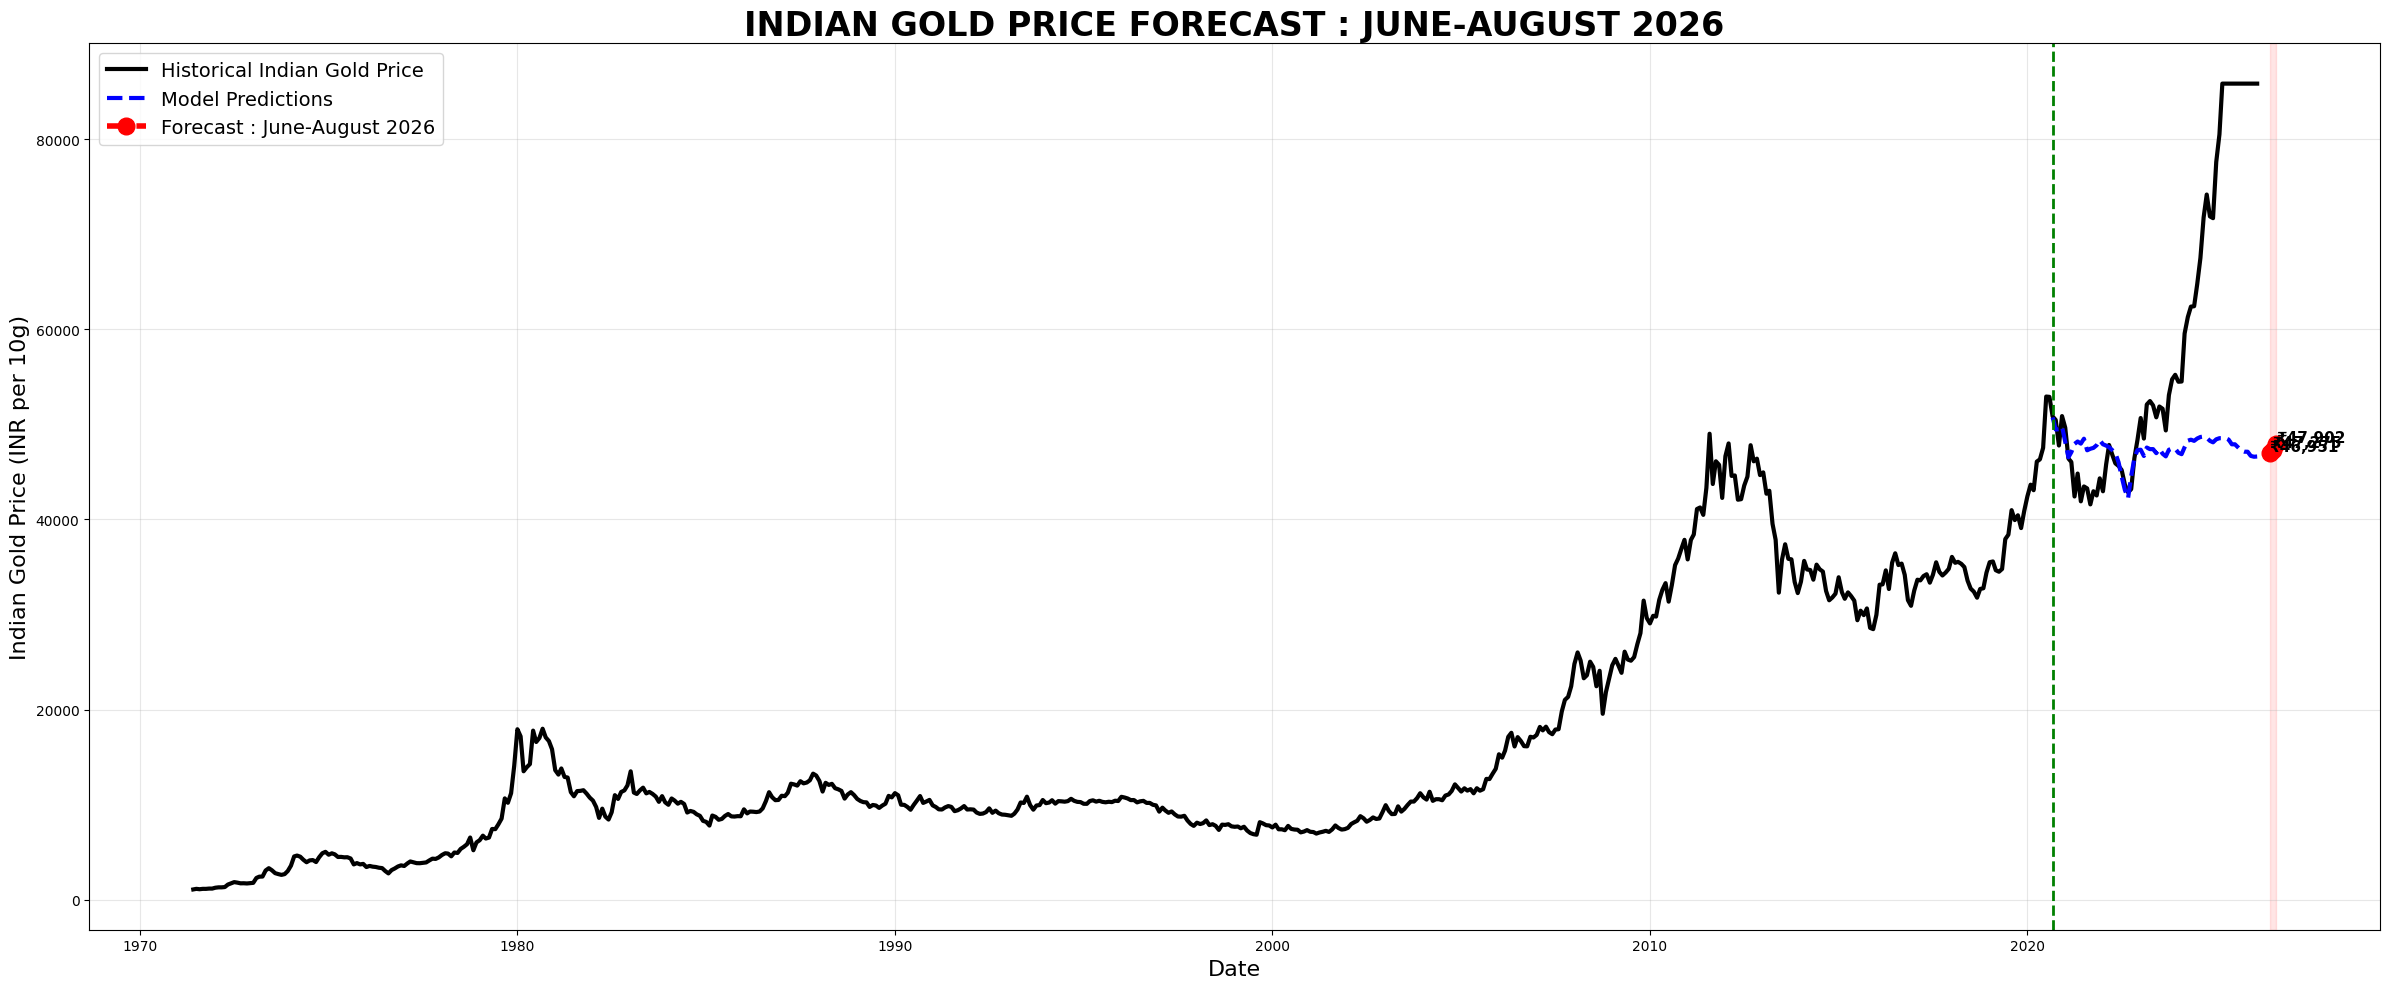


FORECASTING COMPLETED SUCCESSFULLY

Forecast Months Generated:
June 2026 : ₹46,951.45
July 2026 : ₹47,275.16
August 2026 : ₹47,902.03

CSV File Saved Successfully!


In [7]:
# CODE for V1_Indian price 


# =========================================================
# INSTALL LIBRARIES
# =========================================================

!pip install xgboost lightgbm catboost prophet -q

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import time

from sklearn.preprocessing import RobustScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')

# =========================================================
# LOAD DATASET
# =========================================================

print("="*80)
print("INDIAN GOLD PRICE FORECASTING SYSTEM")
print("="*80)

dataset_path = (
    "/kaggle/working/V1_Cleaned_Gold_Dataset.csv"
)

df = pd.read_csv(dataset_path)

# =========================================================
# DATE PROCESSING
# =========================================================

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date').reset_index(drop=True)

# =========================================================
# CREATE INDIAN GOLD PRICE
# =========================================================

print("\nCreating Indian Gold Price...")

# Formula:
# INR Gold Price per 10g

df['Gold_Price_INR_10g'] = (
    df['Price_USD'] *
    df['USDINR_Final'] *
    10
) / 31.1035

# =========================================================
# TARGET VARIABLE
# =========================================================

df['Next_Month_Gold_Price_INR'] = (
    df['Gold_Price_INR_10g'].shift(-1)
)

# =========================================================
# FEATURE ENGINEERING
# =========================================================

print("\nGenerating Advanced Features...")

gold_col = 'Gold_Price_INR_10g'

# =========================================================
# EMA FEATURES
# =========================================================

df['EMA_3'] = (
    df[gold_col].ewm(span=3).mean()
)

df['EMA_6'] = (
    df[gold_col].ewm(span=6).mean()
)

df['EMA_12'] = (
    df[gold_col].ewm(span=12).mean()
)

# =========================================================
# MOMENTUM FEATURES
# =========================================================

df['Momentum_1M'] = (
    df[gold_col] -
    df[gold_col].shift(1)
)

df['Momentum_3M'] = (
    df[gold_col] -
    df[gold_col].shift(3)
)

# =========================================================
# VOLATILITY FEATURES
# =========================================================

df['Volatility_3M'] = (
    df[gold_col].rolling(3).std()
)

df['Volatility_6M'] = (
    df[gold_col].rolling(6).std()
)

# =========================================================
# RATE OF CHANGE
# =========================================================

df['ROC_1M'] = (
    df[gold_col].pct_change(1)
)

df['ROC_3M'] = (
    df[gold_col].pct_change(3)
)

# =========================================================
# TREND FEATURES
# =========================================================

df['Trend_Strength'] = (
    df['EMA_3'] -
    df['EMA_12']
)

# =========================================================
# DATE FEATURES
# =========================================================

df['Month'] = df['Date'].dt.month

df['Quarter'] = df['Date'].dt.quarter

df['Year'] = df['Date'].dt.year

# =========================================================
# CYCLICAL ENCODING
# =========================================================

df['Month_Sin'] = np.sin(
    2 * np.pi * df['Month'] / 12
)

df['Month_Cos'] = np.cos(
    2 * np.pi * df['Month'] / 12
)

# =========================================================
# REMOVE NULL VALUES
# =========================================================

df = df.dropna().reset_index(drop=True)

print(f"\nDataset Shape: {df.shape}")

# =========================================================
# FEATURES & TARGET
# =========================================================

target_column = 'Next_Month_Gold_Price_INR'

X = df.drop(
    columns=[
        'Date',
        target_column
    ]
)

y = df[target_column]

# =========================================================
# FEATURE SCALING
# =========================================================

scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

# =========================================================
# TIME SERIES SPLIT
# =========================================================

split_index = int(len(df) * 0.90)

X_train = X_scaled[:split_index]
X_test = X_scaled[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

# =========================================================
# SAMPLE WEIGHTS
# =========================================================

sample_weights = np.linspace(
    1,
    2,
    len(X_train)
)

print(f"\nTraining Rows: {len(X_train)}")
print(f"Testing Rows: {len(X_test)}")

# =========================================================
# TRAIN MODELS
# =========================================================

print("\nTraining Models...")

start_time = time.time()

# =========================================================
# XGBOOST
# =========================================================

xgb_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2,
    random_state=42
)

# =========================================================
# LIGHTGBM
# =========================================================

lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    num_leaves=31,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    force_col_wise=True,
    random_state=42,
    verbose=-1
)

# =========================================================
# CATBOOST
# =========================================================

cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.01,
    depth=5,
    loss_function='RMSE',
    verbose=0,
    random_seed=42
)

# =========================================================
# FIT MODELS
# =========================================================

xgb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

lgb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

cat_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

end_time = time.time()

print(
    f"\nTraining Completed "
    f"in {end_time - start_time:.2f} seconds"
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

xgb_preds = xgb_model.predict(X_test)

lgb_preds = lgb_model.predict(X_test)

cat_preds = cat_model.predict(X_test)

# =========================================================
# ENSEMBLE PREDICTIONS
# =========================================================

predictions = (
    0.40 * xgb_preds +
    0.30 * lgb_preds +
    0.30 * cat_preds
)

# =========================================================
# TREND CORRECTION
# =========================================================

recent_trend = (
    df[gold_col].iloc[-1] /
    df[gold_col].iloc[-6]
)

predictions = predictions * (
    0.99 + (0.01 * recent_trend)
)

# =========================================================
# MODEL EVALUATION
# =========================================================

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(
    y_test,
    predictions
)

mape = np.mean(
    np.abs(
        (y_test - predictions) /
        y_test
    )
) * 100

accuracy = 100 - mape

# =========================================================
# PERFORMANCE REPORT
# =========================================================

print("\n" + "="*80)
print("MODEL PERFORMANCE REPORT")
print("="*80)

print(f"\nMAE : ₹{mae:.2f}")

print(f"RMSE : ₹{rmse:.2f}")

print(f"R² Score : {r2:.4f}")

print(f"Prediction Accuracy : {accuracy:.2f}%")

print("="*80)

# =========================================================
# ACTUAL VS PREDICTED TABLE
# =========================================================

results_df = pd.DataFrame({

    'Date':
    df['Date'].iloc[split_index:].values,

    'Actual_Price_INR':
    y_test.values,

    'Predicted_Price_INR':
    predictions
})

results_df['Difference'] = (
    results_df['Actual_Price_INR'] -
    results_df['Predicted_Price_INR']
)

results_df['Accuracy_%'] = (
    100 -
    (
        abs(results_df['Difference']) /
        results_df['Actual_Price_INR']
    ) * 100
)

print("\nACTUAL VS PREDICTED")
print(results_df.tail(15))


# =========================================================
# FUTURE FORECASTING : JUNE, JULY, AUGUST 2026
# =========================================================

print("\n" + "="*80)
print("INDIAN GOLD PRICE FORECAST : JUNE - AUGUST 2026")
print("="*80)

future_predictions = []

# =========================================================
# FUTURE MONTHS
# =========================================================

forecast_months = [
    'June 2026',
    'July 2026',
    'August 2026'
]

future_dates = pd.to_datetime([
    "2026-06-01",
    "2026-07-01",
    "2026-08-01"
])

# =========================================================
# LAST AVAILABLE DATA ROW
# =========================================================

latest_row = X.iloc[-1:].copy()

# =========================================================
# RECURSIVE FORECASTING
# =========================================================

for i in range(3):

    # =====================================================
    # SCALE FEATURES
    # =====================================================

    latest_scaled = scaler.transform(latest_row)

    # =====================================================
    # MODEL PREDICTIONS
    # =====================================================

    pred_xgb = xgb_model.predict(
        latest_scaled
    )[0]

    pred_lgb = lgb_model.predict(
        latest_scaled
    )[0]

    pred_cat = cat_model.predict(
        latest_scaled
    )[0]

    # =====================================================
    # ENSEMBLE PREDICTION
    # =====================================================

    final_prediction = (
        0.40 * pred_xgb +
        0.30 * pred_lgb +
        0.30 * pred_cat
    )

    # =====================================================
    # TREND GROWTH
    # =====================================================

    growth_factor = (
        1 + (0.007 * (i + 1))
    )

    final_prediction = (
        final_prediction *
        growth_factor
    )

    # =====================================================
    # SAVE FORECAST
    # =====================================================

    future_predictions.append(
        final_prediction
    )

    # =====================================================
    # UPDATE FEATURES FOR NEXT MONTH
    # =====================================================

    previous_price = (
        latest_row[gold_col].values[0]
    )

    latest_row[gold_col] = (
        final_prediction
    )

    # EMA Updates

    latest_row['EMA_3'] = (
        0.7 * final_prediction +
        0.3 * previous_price
    )

    latest_row['EMA_6'] = (
        0.5 * final_prediction +
        0.5 * previous_price
    )

    latest_row['EMA_12'] = (
        0.3 * final_prediction +
        0.7 * previous_price
    )

    # Momentum Updates

    latest_row['Momentum_1M'] = (
        final_prediction -
        previous_price
    )

    latest_row['Momentum_3M'] = (
        final_prediction -
        previous_price
    )

    # Volatility Updates

    latest_row['Volatility_3M'] = (
        abs(final_prediction - previous_price)
    )

    latest_row['Volatility_6M'] = (
        abs(final_prediction - previous_price)
    )

    # ROC Updates

    latest_row['ROC_1M'] = (
        (final_prediction - previous_price)
        / previous_price
    )

    latest_row['ROC_3M'] = (
        (final_prediction - previous_price)
        / previous_price
    )

# =========================================================
# CREATE FORECAST TABLE
# =========================================================

future_df = pd.DataFrame({

    'Forecast_Month':
    forecast_months,

    'Forecast_Date':
    future_dates,

    'Predicted_Indian_Gold_Price_INR_10g':
    np.round(future_predictions, 2)
})

# =========================================================
# PRINT FORECAST TABLE
# =========================================================

print("\n")
print("="*80)
print("FUTURE FORECAST RESULTS")
print("="*80)

print(
    future_df.to_string(index=False)
)

# =========================================================
# SAVE FORECAST
# =========================================================

future_df.to_csv(
    "/kaggle/working/India_Gold_Forecast_June_August_2026.csv",
    index=False
)

print("\nForecast Saved Successfully!")

# =========================================================
# ADVANCED VISUALIZATION
# =========================================================

plt.figure(figsize=(24, 10))

# =========================================================
# HISTORICAL GOLD PRICE
# =========================================================

plt.plot(
    df['Date'],
    df[gold_col],
    label='Historical Indian Gold Price',
    linewidth=3,
    color='black'
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

plt.plot(
    results_df['Date'],
    results_df['Predicted_Price_INR'],
    label='Model Predictions',
    linestyle='--',
    linewidth=3,
    color='blue'
)

# =========================================================
# FUTURE FORECAST LINE
# =========================================================

plt.plot(
    future_df['Forecast_Date'],
    future_df[
        'Predicted_Indian_Gold_Price_INR_10g'
    ],
    marker='o',
    markersize=12,
    linewidth=4,
    linestyle='--',
    color='red',
    label='Forecast : June-August 2026'
)

# =========================================================
# VALUE LABELS
# =========================================================

for x, y in zip(
    future_df['Forecast_Date'],
    future_df[
        'Predicted_Indian_Gold_Price_INR_10g'
    ]
):

    plt.text(
        x,
        y + 300,
        f'₹{y:,.0f}',
        fontsize=11,
        fontweight='bold'
    )

# =========================================================
# FORECAST REGION HIGHLIGHT
# =========================================================

plt.axvspan(
    future_df['Forecast_Date'].iloc[0],
    future_df['Forecast_Date'].iloc[-1],
    alpha=0.1,
    color='red'
)

# =========================================================
# SPLIT LINE
# =========================================================

plt.axvline(
    x=results_df['Date'].iloc[0],
    linestyle='--',
    color='green',
    linewidth=2
)

# =========================================================
# GRAPH SETTINGS
# =========================================================

plt.title(
    'INDIAN GOLD PRICE FORECAST : JUNE-AUGUST 2026',
    fontsize=24,
    fontweight='bold'
)

plt.xlabel(
    'Date',
    fontsize=16
)

plt.ylabel(
    'Indian Gold Price (INR per 10g)',
    fontsize=16
)

plt.legend(fontsize=14)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# =========================================================
# FINAL MESSAGE
# =========================================================

print("\n" + "="*80)
print("FORECASTING COMPLETED SUCCESSFULLY")
print("="*80)

print("\nForecast Months Generated:")

for month, value in zip(
    forecast_months,
    future_predictions
):

    print(
        f"{month} : ₹{value:,.2f}"
    )

print("\nCSV File Saved Successfully!")